Data columns:
['location', 'nit_perc', 'variety', 'Total(tons/ac)', 'chlgr', 'chlre', 'dvi', 'evi', 'evi2', 'gndvi', 'mari', 'mcari', 'mcaridiosavi', 'msavi', 'msr', 'ndvi', 'osavi', 'pvi', 'savi', 'savi2', 'sr', 'tsavi', 'wdri']

VIP columns:
['Variable', 'VIP', 'Coefficient']

Top features from VIP file:
['mcaridiosavi', 'mcari', 'gndvi', 'chlre', 'mari', 'chlgr']

Top features found in dataset:
['mcaridiosavi', 'mcari', 'gndvi', 'chlre', 'mari', 'chlgr']

Final modeling shape:
X: (120, 6)
y: (120,)

XGBoost detected and added.

Training SVR
Best parameters: {'model__C': 100, 'model__epsilon': 0.2, 'model__gamma': 'auto', 'model__kernel': 'rbf'}
R    : 0.425475447772619
RMSE : 5.554775033566194
MAE  : 4.21993055327868
Bias : -0.7964671887697975

Training RF
Best parameters: {'max_depth': 12, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
R    : 0.4099781960142326
RMSE : 5.082042861212805
MAE  : 3.9963792308106396
Bias : 0.14309430422965752

Training ExtraTrees
Be

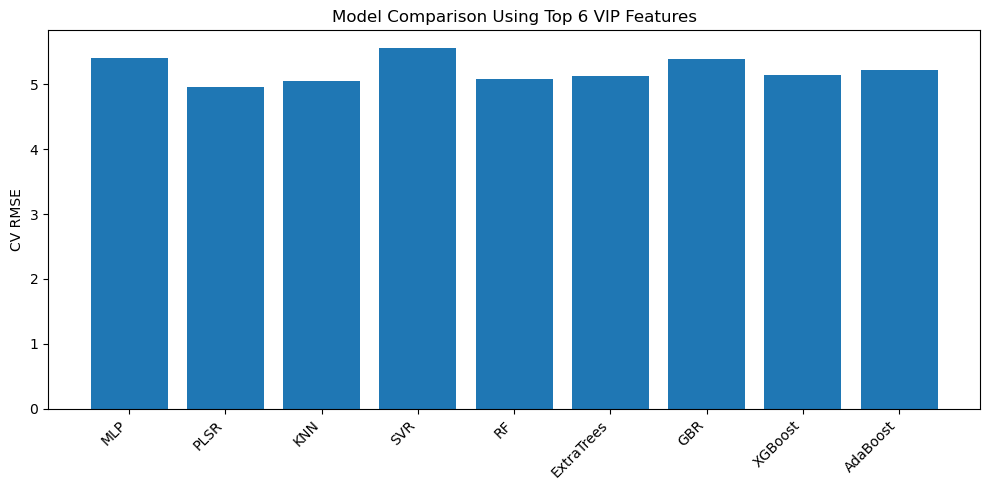

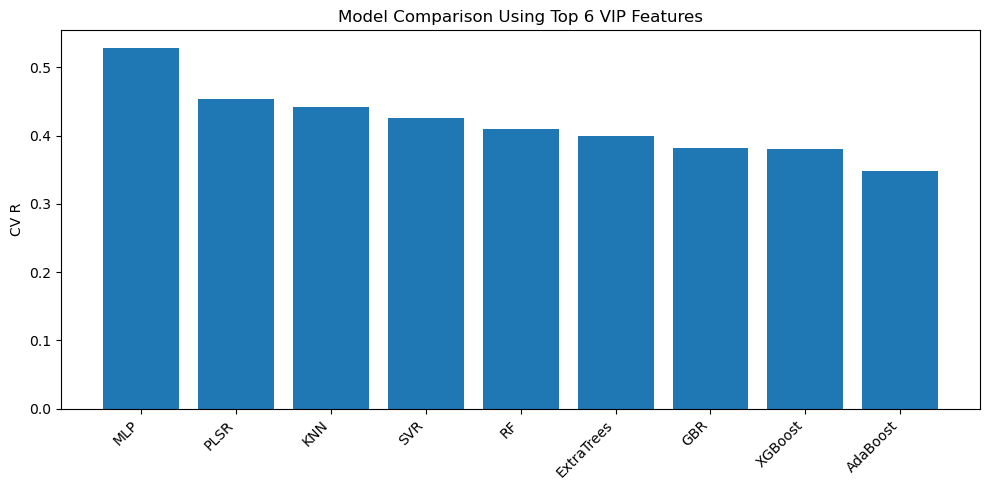

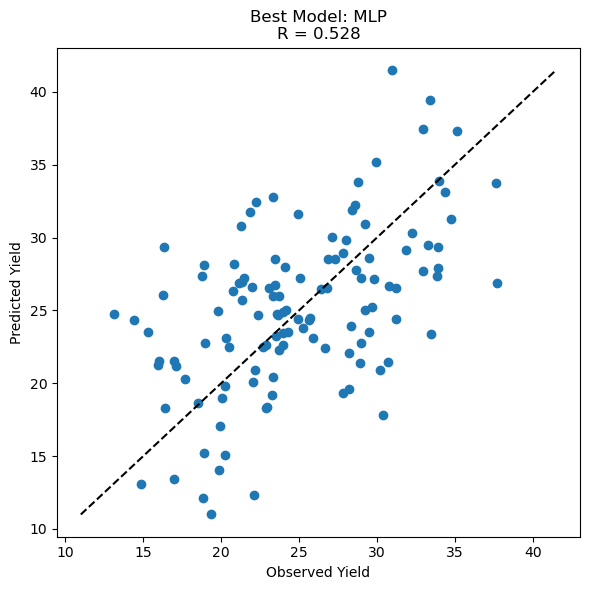

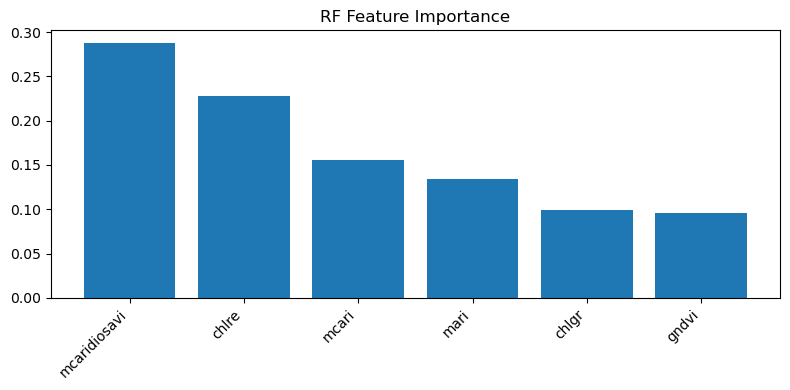

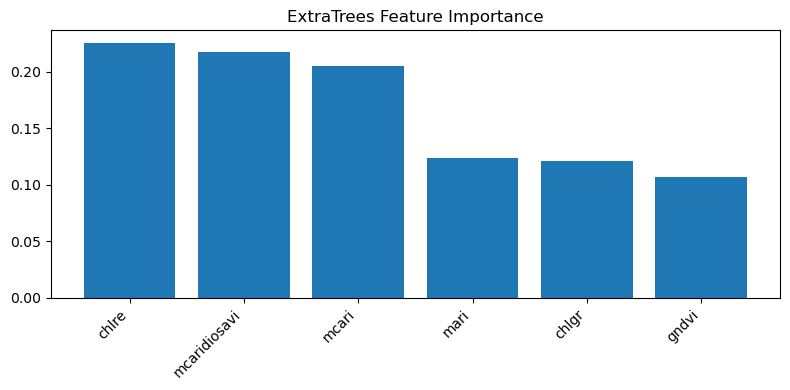

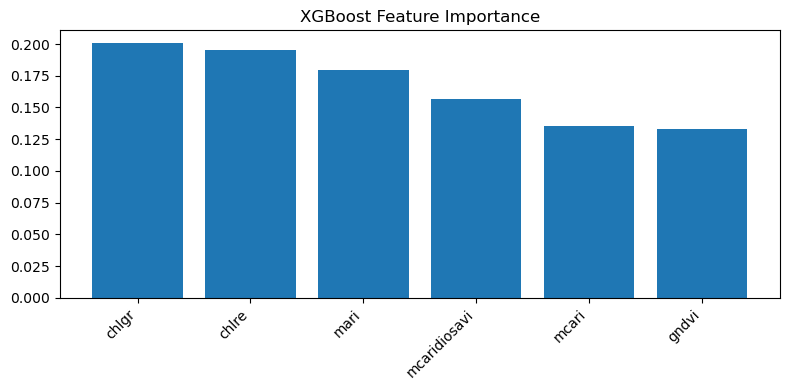

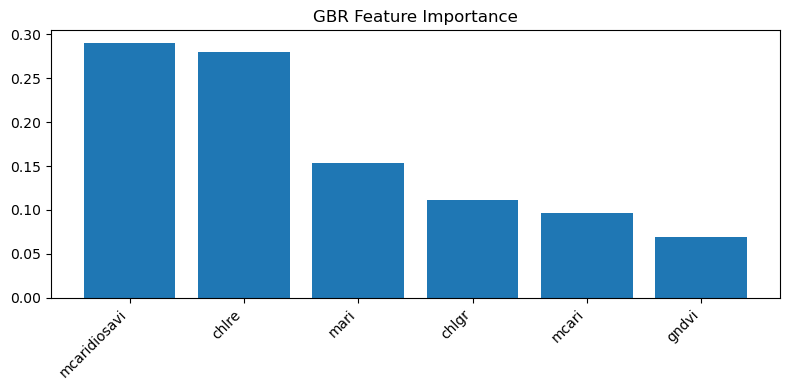

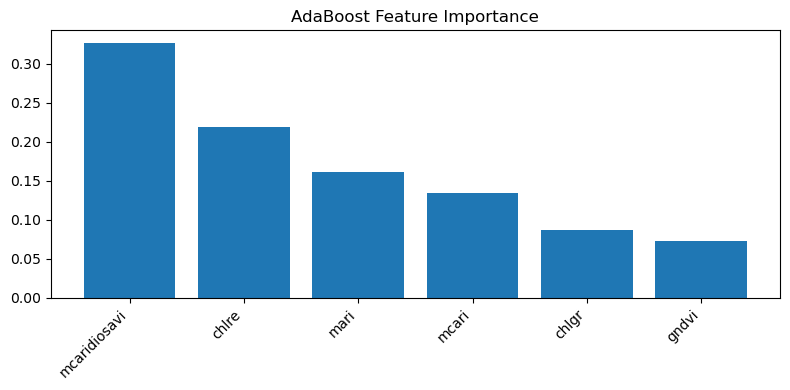


Done.
Top 6 features used: ['mcaridiosavi', 'mcari', 'gndvi', 'chlre', 'mari', 'chlgr']
Best model: MLP


In [1]:
#   “Copyright (C) 2024 Mississippi State University.
 
#    This program is free software: you can redistribute it and/or modify
#    it under the terms of the GNU General Public License as published by
#    the Free Software Foundation, either version 3 of the License, or
#    (at your option) any later version.
 
#    This program is distributed in the hope that it will be useful,
#    but WITHOUT ANY WARRANTY; without even the implied warranty of
#    MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
#    GNU General Public License for more details.
 
#    You should have received a copy of the GNU General Public License
#    along with this program.  If not, see <https://www.gnu.org/licenses/>.
 
# To inquire about relicensing, accessing more training data, collaborating with the author, or any general inquiry about the software, please contact Mississippi State University’s Office of Technology Management at otm@msstate.edu, (662) 325-9263.”


# Dependency Libraries

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, make_scorer

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.neural_network import MLPRegressor

warnings.filterwarnings("ignore")


# INPUT FILES

data_path = r"C:\Users\Say70\OneDrive - Mississippi State University\Desktop\UGA talk\Yield Data\Yield Data_vs_6_10_2020_VIs.xlsx"
vip_path  = r"C:\Users\Say70\OneDrive - Mississippi State University\Desktop\UGA talk\Yield Data\PLSR_VIP_Ranking.xlsx"

output_dir = r"C:\Users\Say70\OneDrive - Mississippi State University\Desktop\UGA talk\Yield Data\Model_Results"
os.makedirs(output_dir, exist_ok=True)


# SETTINGS

target_name = "Total(tons/ac)"
top_k = 6
random_state = 42
n_splits = 5


# LOAD DATA

df = pd.read_excel(data_path)
vip_df = pd.read_excel(vip_path)

print("Data columns:")
print(df.columns.tolist())
print("\nVIP columns:")
print(vip_df.columns.tolist())

# Clean VIP names
vip_df["Variable"] = vip_df["Variable"].astype(str).str.strip()
df.columns = [str(c).strip() for c in df.columns]

# Top VIP features
top_features = vip_df.sort_values("VIP", ascending=False)["Variable"].head(top_k).tolist()
print("\nTop features from VIP file:")
print(top_features)

# Keep only features that exist in data
top_features = [f for f in top_features if f in df.columns]
print("\nTop features found in dataset:")
print(top_features)

if len(top_features) == 0:
    raise ValueError("No top VIP features were found in the dataset columns.")

if len(top_features) < top_k:
    print(f"\nWarning: only {len(top_features)} of requested top {top_k} features were found.")

if target_name not in df.columns:
    raise ValueError(f"Target column '{target_name}' not found in dataset.")

# Drop missing / inf
model_df = df[top_features + [target_name]].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()

X = model_df[top_features].values
y = model_df[target_name].values.astype(float)

print("\nFinal modeling shape:")
print("X:", X.shape)
print("y:", y.shape)


# METRICS

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def pearson_r(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) < 2:
        return np.nan

    std_true = np.std(y_true)
    std_pred = np.std(y_pred)

    if std_true < 1e-12 or std_pred < 1e-12:
        return np.nan

    return np.corrcoef(y_true, y_pred)[0, 1]

def evaluate_predictions(y_true, y_pred):
    return {
        "R": pearson_r(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "Bias": np.mean(y_pred - y_true)
    }

corr_scorer = make_scorer(pearson_r, greater_is_better=True)


# MODELS + PARAMETER GRIDS

models = {
    "SVR": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR())
        ]),
        {
            "model__kernel": ["rbf", "linear"],
            "model__C": [0.1, 1, 10, 50, 100],
            "model__epsilon": [0.01, 0.05, 0.1, 0.2],
            "model__gamma": ["scale", "auto"]
        }
    ),

    "RF": (
        RandomForestRegressor(random_state=random_state),
        {
            "n_estimators": [100, 200, 400],
            "max_depth": [None, 3, 5, 8, 12],
            "min_samples_split": [2, 4, 6],
            "min_samples_leaf": [1, 2, 4]
        }
    ),

    "ExtraTrees": (
        ExtraTreesRegressor(random_state=random_state),
        {
            "n_estimators": [100, 200, 400],
            "max_depth": [None, 3, 5, 8, 12],
            "min_samples_split": [2, 4, 6],
            "min_samples_leaf": [1, 2, 4]
        }
    ),

    "GBR": (
        GradientBoostingRegressor(random_state=random_state),
        {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [2, 3, 4],
            "subsample": [0.7, 0.85, 1.0]
        }
    ),

    "AdaBoost": (
        AdaBoostRegressor(random_state=random_state),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0]
        }
    ),

    "KNN": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsRegressor())
        ]),
        {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        }
    ),

    "PLSR": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", PLSRegression())
        ]),
        {
            "model__n_components": list(range(1, min(len(top_features), 6) + 1))
        }
    ),

    "MLP": (
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(random_state=random_state, max_iter=3000))
        ]),
        {
            "model__hidden_layer_sizes": [(16,), (32,), (64,), (32, 16)],
            "model__activation": ["relu", "tanh"],
            "model__alpha": [0.0001, 0.001, 0.01],
            "model__learning_rate_init": [0.001, 0.01]
        }
    )
}

# Optional XGBoost
try:
    from xgboost import XGBRegressor
    models["XGBoost"] = (
        XGBRegressor(
            random_state=random_state,
            objective="reg:squarederror",
            n_jobs=-1
        ),
        {
            "n_estimators": [100, 200, 400],
            "max_depth": [2, 3, 4, 5],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.7, 0.85, 1.0],
            "colsample_bytree": [0.7, 0.85, 1.0]
        }
    )
    print("\nXGBoost detected and added.")
except Exception:
    print("\nXGBoost not available. Skipping it.")


# CROSS-VALIDATION

cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

results = []
best_estimators = {}
cv_predictions = {}

for model_name, (estimator, param_grid) in models.items():
    print(f"\n{'='*70}")
    print(f"Training {model_name}")
    print(f"{'='*70}")

    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=corr_scorer,
        cv=cv,
        n_jobs=-1,
        refit=True
    )

    search.fit(X, y)
    best_model = search.best_estimator_
    best_estimators[model_name] = best_model

    y_pred_cv = cross_val_predict(best_model, X, y, cv=cv, n_jobs=-1)
    cv_predictions[model_name] = y_pred_cv

    metrics = evaluate_predictions(y, y_pred_cv)
    metrics["Model"] = model_name
    metrics["Best_Params"] = str(search.best_params_)
    results.append(metrics)

    print("Best parameters:", search.best_params_)
    print("R    :", metrics["R"])
    print("RMSE :", metrics["RMSE"])
    print("MAE  :", metrics["MAE"])
    print("Bias :", metrics["Bias"])


# SAVE RESULTS TABLE

results_df = pd.DataFrame(results)
results_df = results_df[["Model", "R", "RMSE", "MAE", "Bias", "Best_Params"]]
results_df = results_df.sort_values("R", ascending=False).reset_index(drop=True)

results_csv = os.path.join(output_dir, "top6_models_performance.csv")
results_xlsx = os.path.join(output_dir, "top6_models_performance.xlsx")

results_df.to_csv(results_csv, index=False)
try:
    results_df.to_excel(results_xlsx, index=False)
except Exception as e:
    print("\nExcel save failed:", e)

print("\nSaved performance table to:")
print(results_csv)
print(results_xlsx)

print("\nModel ranking:")
print(results_df)


# SAVE FEATURE INFO

feature_df = pd.DataFrame({
    "Selected_Top_Features": top_features
})
feature_csv = os.path.join(output_dir, "top6_selected_features.csv")
feature_df.to_csv(feature_csv, index=False)


# PLOT MODEL COMPARISON

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.ylabel("CV RMSE")
plt.title("Model Comparison Using Top 6 VIP Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "model_comparison_rmse.png"), dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["R"])
plt.ylabel("CV R")
plt.title("Model Comparison Using Top 6 VIP Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "model_comparison_r.png"), dpi=300)
plt.show()


# PLOT BEST MODEL PREDICTED VS OBSERVED

best_model_name = results_df.iloc[0]["Model"]
best_y_pred = cv_predictions[best_model_name]
best_r = pearson_r(y, best_y_pred)

plt.figure(figsize=(6, 6))
plt.scatter(y, best_y_pred)
mn = min(np.min(y), np.min(best_y_pred))
mx = max(np.max(y), np.max(best_y_pred))
plt.plot([mn, mx], [mn, mx], "k--")
plt.xlabel("Observed Yield")
plt.ylabel("Predicted Yield")
plt.title(f"Best Model: {best_model_name}\nR = {best_r:.3f}")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, f"{best_model_name}_observed_vs_predicted.png"), dpi=300)
plt.show()


# OPTIONAL: FEATURE IMPORTANCE FOR TREE MODELS

tree_models = ["RF", "ExtraTrees", "XGBoost", "GBR", "AdaBoost"]

for model_name in tree_models:
    if model_name not in best_estimators:
        continue

    model = best_estimators[model_name]

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "named_steps") and hasattr(model.named_steps.get("model", None), "feature_importances_"):
        importances = model.named_steps["model"].feature_importances_
    else:
        continue

    imp_df = pd.DataFrame({
        "Feature": top_features,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    imp_df.to_csv(os.path.join(output_dir, f"{model_name}_feature_importance.csv"), index=False)

    plt.figure(figsize=(8, 4))
    plt.bar(imp_df["Feature"], imp_df["Importance"])
    plt.title(f"{model_name} Feature Importance")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"{model_name}_feature_importance.png"), dpi=300)
    plt.show()

print("\nDone.")
print("Top 6 features used:", top_features)
print("Best model:", best_model_name)